In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

class_results = []

def plot_decision_boundary(model_name, remarks, X_train, X_test, y_train, y_test, model):
    # Predict and calculate Accuracy
    train_acc = accuracy_score(y_train, model.predict(X_train))
    test_acc = accuracy_score(y_test, model.predict(X_test))
    
    class_results.append({
        "Model": model_name,
        "Remarks": remarks,
        "Train Accuracy": round(train_acc, 3),
        "Test Accuracy": round(test_acc, 3)
    })
    
    # Create a meshgrid to paint the decision boundary background
    x_min, x_max = X_train[:, 0].min() - 0.5, X_train[:, 0].max() + 0.5
    y_min, y_max = X_train[:, 1].min() - 0.5, X_train[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                         np.arange(y_min, y_max, 0.02))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    
    # Side-by-Side Plots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    fig.suptitle(f"{model_name} | {remarks}", fontsize=14, fontweight='bold')
    
    # LEFT: Training Data
    ax1.contourf(xx, yy, Z, alpha=0.3, cmap='Wistia')
    ax1.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap='Wistia', edgecolor='black', s=40)
    ax1.set_title(f"TRAIN Data (Acc: {train_acc:.2f})")
    
    # RIGHT: Unseen Test Data
    ax2.contourf(xx, yy, Z, alpha=0.3, cmap='Wistia')
    ax2.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap='Wistia', edgecolor='black', s=40)
    ax2.set_title(f"UNSEEN TEST Data (Acc: {test_acc:.2f})")
    
    plt.tight_layout()
    plt.show()

# --- GENERATE THE MOONS DATASET ---
# We use noise=0.25 to make the classes overlap a bit, preventing a "too easy" perfect score
X_moons, y_moons = make_moons(n_samples=400, noise=0.50, random_state=42)
X_train_C, X_test_C, y_train_C, y_test_C = train_test_split(X_moons, y_moons, test_size=0.25, random_state=42)

# Part 2: Classification (Drawing the Boundaries)
In this section, we want to separate our data into discrete classes (Yellow vs. Orange). Our dataset consists of two interlocking half-moons with significant noise. Let's watch how different algorithms attempt to draw the boundary between them.

## 1. The Linear Baseline: Logistic Regression
Despite its name, Logistic Regression is a classification algorithm. However, it is strictly linear. Let's see what happens when we ask it to solve a curved problem.

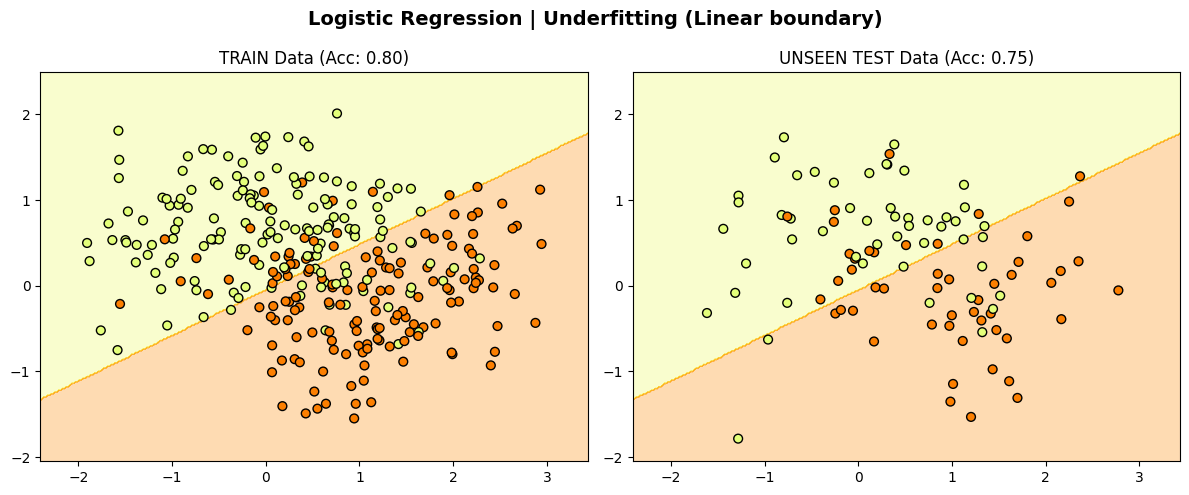

In [3]:
# Initialize and fit Logistic Regression
log_clf = LogisticRegression()
log_clf.fit(X_train_C, y_train_C)

plot_decision_boundary("Logistic Regression", "Underfitting (Linear boundary)", 
                       X_train_C, X_test_C, y_train_C, y_test_C, log_clf)

## 2. The Overfit: Unconstrained Decision Tree
Decision Trees can map non-linear data by continuously splitting the feature space into rectangles. However, if we don't restrict its depth, it will memorize every single dot of noise.

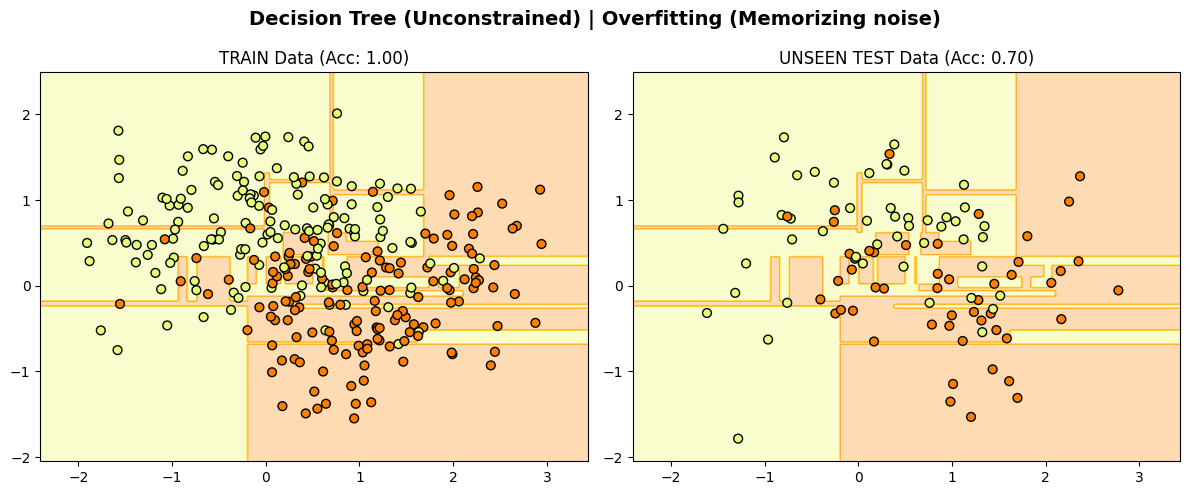

In [4]:
# Initialize a Decision Tree with NO max depth
tree_clf = DecisionTreeClassifier(random_state=42)
tree_clf.fit(X_train_C, y_train_C)

plot_decision_boundary("Decision Tree (Unconstrained)", "Overfitting (Memorizing noise)", 
                       X_train_C, X_test_C, y_train_C, y_test_C, tree_clf)

## 3. The Ensemble Fix: Random Forest
To fix the jagged, overfitted tree, we use an Ensemble method. A Random Forest builds 100 different, slightly randomized Decision Trees and lets them "vote." This averages out the overfitting, creating a beautiful, smooth boundary.

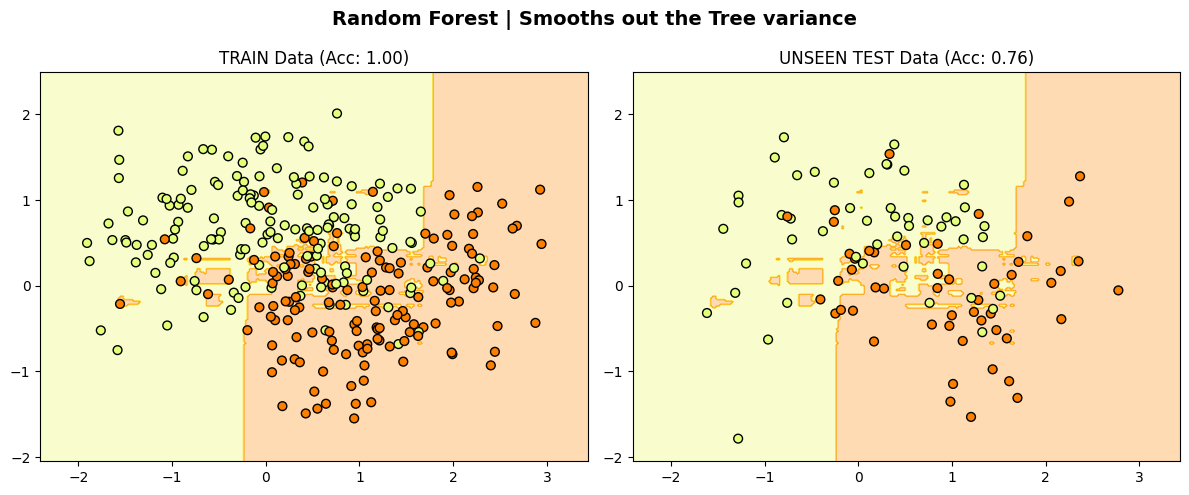

In [6]:
# Initialize a Random Forest with 100 trees
rf_clf = RandomForestClassifier(n_estimators = 100, random_state=42)
rf_clf.fit(X_train_C, y_train_C)

plot_decision_boundary("Random Forest", "Smooths out the Tree variance", 
                       X_train_C, X_test_C, y_train_C, y_test_C, rf_clf)

## 4. The Distance Approach: k-Nearest Neighbors (k-NN)
Instead of drawing a global mathematical boundary or building rules, what if we just look at the points closest to us? k-NN classifies a point based on a majority vote of its `k` nearest neighbors. We will use `k=15` to ensure the algorithm looks at a wide enough neighborhood to ignore isolated noise dots.

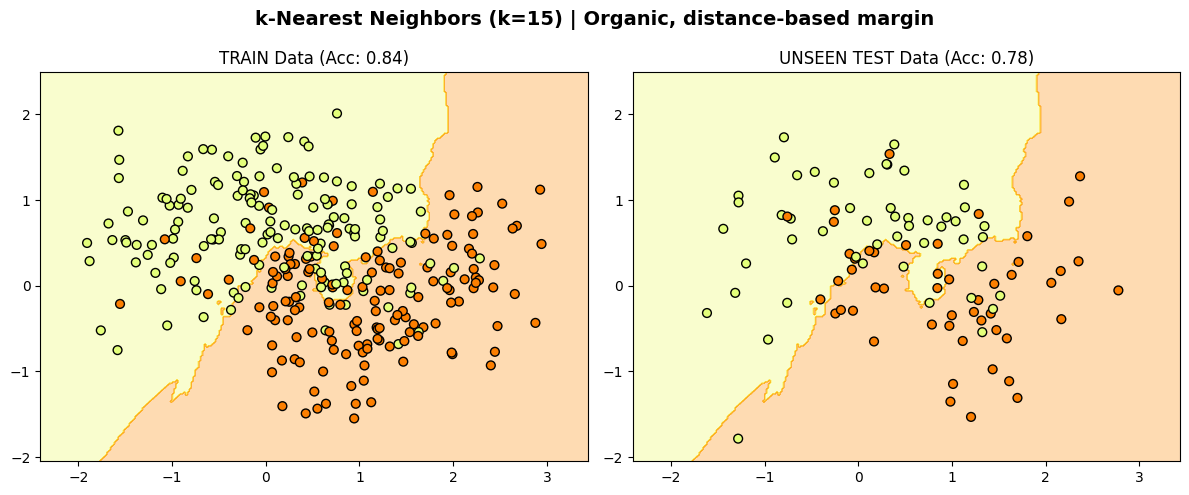

In [11]:
from sklearn.neighbors import KNeighborsClassifier

# Initialize k-NN with 15 neighbors to smooth out the severe noise
knn_clf = KNeighborsClassifier(n_neighbors = 15)
knn_clf.fit(X_train_C, y_train_C)

plot_decision_boundary("k-Nearest Neighbors (k=15)", "Organic, distance-based margin", 
                       X_train_C, X_test_C, y_train_C, y_test_C, knn_clf)

In [12]:
# Display the classification comparison table
df_class = pd.DataFrame(class_results)
display(df_class)

,Model,Remarks,Train Accuracy,Test Accuracy
0,Logistic Regression,Underfitting (Linear boundary),0.797,0.75
1,Decision Tree (Unconstrained),Overfitting (Memorizing noise),1.000,0.70
2,Random Forest,Smooths out the Tree variance,1.000,0.76
3,k-Nearest Neighbors (k=15),"Organic, distance-based margin",0.837,0.78
4,k-Nearest Neighbors (k=15),"Organic, distance-based margin",0.850,0.73
5,k-Nearest Neighbors (k=15),"Organic, distance-based margin",0.837,0.78
